# 05. Modeling

SECOM의 클래스 불균형을 고려해 Feature subset A/B/C/D와 기본 모델을 train 내부 CV로 비교하고 explainability 후보를 고른다. Test set은 모델과 decision threshold를 확정한 후 한 번만 평가한다. SMOTE, PCA, SHAP, exhaustive tuning은 수행하지 않는다.

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Project root could not be resolved from {cwd}')
os.environ['MPLCONFIGDIR'] = str(PROJECT_ROOT / '.cache' / 'matplotlib')
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.load_data import load_secom_dataset, split_secom_data

REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
MISSING_THRESHOLD = 0.40
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sns.set_theme(style='whitegrid')

## 1. Reproduce the outer split and train-fitted preprocessing

Step 7과 동일하게 timestamp를 제외하고 Pass(-1)→0, Fail(1)→1을 별도 Target으로 사용한다. Constant, 40% 초과 결측률, median은 outer train에서만 계산하고 test에는 동일 열과 train median만 적용한다.

In [2]:
dataset = load_secom_dataset()
X_raw, y_frame = split_secom_data(dataset)
X_numeric = X_raw.drop(columns='timestamp').copy()
y_original = y_frame['class'].copy()
y = y_original.map({-1: 0, 1: 1}).astype(int)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
constant_features = X_train_raw.columns[X_train_raw.nunique(dropna=True) <= 1].tolist()
after_constant = [c for c in X_train_raw.columns if c not in constant_features]
train_missing_rate = X_train_raw[after_constant].isna().mean()
high_missing_features = train_missing_rate[train_missing_rate > MISSING_THRESHOLD].index.tolist()
preprocessed_features = [c for c in after_constant if c not in high_missing_features]
train_medians = X_train_raw[preprocessed_features].median()
X_train = X_train_raw[preprocessed_features].fillna(train_medians)
X_test = X_test_raw[preprocessed_features].fillna(train_medians)
feature_subsets = json.loads((REPORTS_DIR / 'feature_subsets.json').read_text(encoding='utf-8'))
assert (len(X_train), len(X_test), int(y_train.sum()), int(y_test.sum())) == (1253, 314, 83, 21)
assert list(X_train.columns) == feature_subsets['A_preprocessed_all']
for features in feature_subsets.values():
    assert set(features).issubset(X_train.columns)
print(f'Train/Test: {len(X_train)}/{len(X_test)}; Fail: {int(y_train.sum())}/{int(y_test.sum())}')
print({name: len(features) for name, features in feature_subsets.items()})

Train/Test: 1253/314; Fail: 83/21
{'A_preprocessed_all': 442, 'B_correlation_pruned': 270, 'C_correlation_plus_univariate': 69, 'D_correlation_plus_model_based': 91}


## 2. Fair train-CV comparison

Primary metric은 positive class가 드문 상황에서 precision-recall trade-off를 직접 반영하는 Average Precision(PR-AUC)이다. ROC-AUC, Fail recall·precision·F1, balanced accuracy를 함께 기록한다. Accuracy 단독 평가는 사용하지 않는다.

A/B/C/D는 Step 7 outer train에서 생성된 고정 후보다. 따라서 CV는 동일 후보의 모델 비교에는 공정하지만, C/D selection 자체까지 fold 안에서 다시 fit하는 fully nested CV는 아니다. Test는 계속 격리되며 최종 결과 해석에서 이 conditional-CV 한계를 고려한다.

In [3]:
model_builders = {
    'Dummy_prior': lambda: DummyClassifier(strategy='prior'),
    'Logistic': lambda: Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    'Logistic_balanced': lambda: Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'RandomForest_balanced': lambda: RandomForestClassifier(
        n_estimators=300, class_weight='balanced_subsample', random_state=RANDOM_STATE,
        n_jobs=-1, max_features='sqrt'
    ),
    'HistGradientBoosting_balanced': lambda: HistGradientBoostingClassifier(
        class_weight='balanced', max_iter=150, learning_rate=0.08,
        l2_regularization=1.0, random_state=RANDOM_STATE
    ),
}
scoring = {
    'average_precision': 'average_precision', 'roc_auc': 'roc_auc',
    'recall_fail': 'recall', 'precision_fail': 'precision',
    'f1_fail': 'f1', 'balanced_accuracy': 'balanced_accuracy',
}
cv_rows = []
for subset_name, features in feature_subsets.items():
    for model_name, builder in model_builders.items():
        result = cross_validate(builder(), X_train[features], y_train, cv=CV, scoring=scoring, n_jobs=1, error_score='raise')
        row = {'subset': subset_name, 'feature_count': len(features), 'model': model_name}
        for metric in scoring:
            values = result[f'test_{metric}']
            row[f'cv_{metric}_mean'] = float(np.mean(values))
            row[f'cv_{metric}_std'] = float(np.std(values, ddof=1))
        cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows).sort_values('cv_average_precision_mean', ascending=False).reset_index(drop=True)
cv_results.to_csv(REPORTS_DIR / 'model_cv_results.csv', index=False)
display(cv_results)

C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


C:\Projects\semiconductor-secom-yield-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,subset,feature_count,model,cv_average_precision_mean,cv_average_precision_std,cv_roc_auc_mean,cv_roc_auc_std,cv_recall_fail_mean,cv_recall_fail_std,cv_precision_fail_mean,cv_precision_fail_std,cv_f1_fail_mean,cv_f1_fail_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std
0,D_correlation_plus_model_based,91,RandomForest_balanced,0.274255,0.031163,0.783923,0.036624,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
1,C_correlation_plus_univariate,69,HistGradientBoosting_balanced,0.250287,0.083871,0.728375,0.050078,0.072794,0.050836,0.400000,0.379144,0.121153,0.086605,0.532551,0.025997
2,D_correlation_plus_model_based,91,HistGradientBoosting_balanced,0.237079,0.086980,0.756630,0.091757,0.047059,0.076696,0.150000,0.223607,0.071222,0.113755,0.518401,0.037462
3,B_correlation_pruned,270,HistGradientBoosting_balanced,0.212474,0.058343,0.702784,0.087170,0.035294,0.052613,0.200000,0.273861,0.059148,0.086413,0.515510,0.025175
4,A_preprocessed_all,442,RandomForest_balanced,0.207658,0.100801,0.703543,0.080078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
5,D_correlation_plus_model_based,91,Logistic,0.207025,0.074194,0.693153,0.061309,0.108824,0.066918,0.216709,0.098980,0.141748,0.078236,0.540737,0.031953
6,C_correlation_plus_univariate,69,RandomForest_balanced,0.199835,0.042576,0.735379,0.023396,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
7,B_correlation_pruned,270,RandomForest_balanced,0.188265,0.058279,0.689249,0.038208,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
8,D_correlation_plus_model_based,91,Logistic_balanced,0.182026,0.047602,0.690008,0.068123,0.447059,0.108987,0.142088,0.041089,0.213595,0.053071,0.624384,0.055886
9,A_preprocessed_all,442,HistGradientBoosting_balanced,0.175807,0.055424,0.686642,0.084369,0.011765,0.026307,0.050000,0.111803,0.019048,0.042592,0.503318,0.011145


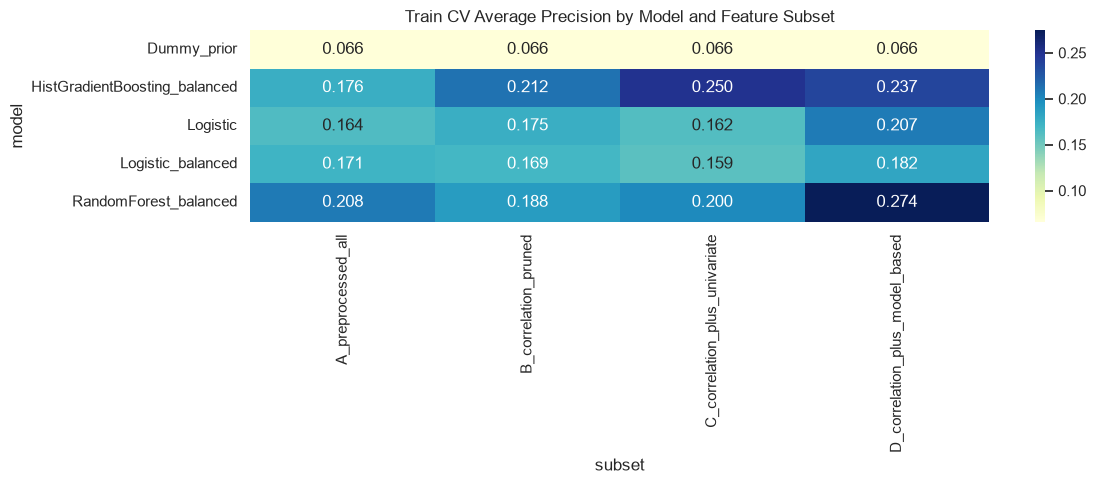

In [4]:
pivot_ap = cv_results.pivot(index='model', columns='subset', values='cv_average_precision_mean')
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot_ap, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Train CV Average Precision by Model and Feature Subset')
fig.tight_layout()
cv_figure = FIGURES_DIR / 'modeling_cv_pr_auc_comparison.png'
fig.savefig(cv_figure, dpi=160, bbox_inches='tight')
plt.show()

## 3. Select a candidate with a simplicity rule

최고 CV Average Precision과 0.01 이내인 조합을 실질적으로 유사한 후보로 보고, 그 안에서는 Logistic → HistGradientBoosting → RandomForest 순으로 단순 모델을 우선한다. 같은 모델이면 더 작은 Feature subset을 우선한다. Dummy는 sanity baseline이며 최종 후보에서 제외한다. 제한적 비교만으로 충분하므로 별도 hyperparameter grid search는 수행하지 않는다.

In [5]:
eligible = cv_results[cv_results['model'] != 'Dummy_prior'].copy()
best_cv_ap = float(eligible['cv_average_precision_mean'].max())
contenders = eligible[eligible['cv_average_precision_mean'] >= best_cv_ap - 0.01].copy()
complexity_rank = {'Logistic': 1, 'Logistic_balanced': 1, 'HistGradientBoosting_balanced': 2, 'RandomForest_balanced': 3}
contenders['complexity_rank'] = contenders['model'].map(complexity_rank)
selected_row = contenders.sort_values(['complexity_rank', 'feature_count', 'cv_average_precision_mean'], ascending=[True, True, False]).iloc[0]
selected_model_name = selected_row['model']
selected_subset_name = selected_row['subset']
selected_features = feature_subsets[selected_subset_name]
selected_estimator = model_builders[selected_model_name]()
alternate_row = eligible[(eligible['model'] != selected_model_name)].sort_values('cv_average_precision_mean', ascending=False).iloc[0]
explainability_candidates = [
    {'model': selected_model_name, 'subset': selected_subset_name, 'reason': 'Primary CV candidate under simplicity rule'},
    {'model': alternate_row['model'], 'subset': alternate_row['subset'], 'reason': 'Best alternate model family by CV Average Precision'},
]
display(contenders)
print(f"Selected: {selected_model_name} / {selected_subset_name} / CV AP={selected_row['cv_average_precision_mean']:.4f}")
print(explainability_candidates)

,subset,feature_count,model,cv_average_precision_mean,cv_average_precision_std,cv_roc_auc_mean,cv_roc_auc_std,cv_recall_fail_mean,cv_recall_fail_std,cv_precision_fail_mean,cv_precision_fail_std,cv_f1_fail_mean,cv_f1_fail_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,complexity_rank
0,D_correlation_plus_model_based,91,RandomForest_balanced,0.274255,0.031163,0.783923,0.036624,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,3


Selected: RandomForest_balanced / D_correlation_plus_model_based / CV AP=0.2743
[{'model': 'RandomForest_balanced', 'subset': 'D_correlation_plus_model_based', 'reason': 'Primary CV candidate under simplicity rule'}, {'model': 'HistGradientBoosting_balanced', 'subset': 'C_correlation_plus_univariate', 'reason': 'Best alternate model family by CV Average Precision'}]


## 4. Train OOF threshold analysis

선정 모델의 5-fold out-of-fold probability만 사용한다. 제조 불량 누락을 제한하기 위해 **Fail recall ≥ 0.80을 만족하는 threshold 중 precision이 최대**인 값을 선택한다. 동률이면 더 높은 threshold를 선택한다. 이는 0.5를 자동 채택하지 않고 False Negative와 False Positive trade-off를 공개하는 규칙이다.

,threshold,precision,recall,f1,predicted_positive,false_negative
Unnamed 0,0.500000,0.000000,0.000000,0.000000,0.0,83.0
16,0.053333,0.116725,0.807229,0.203957,574.0,16.0


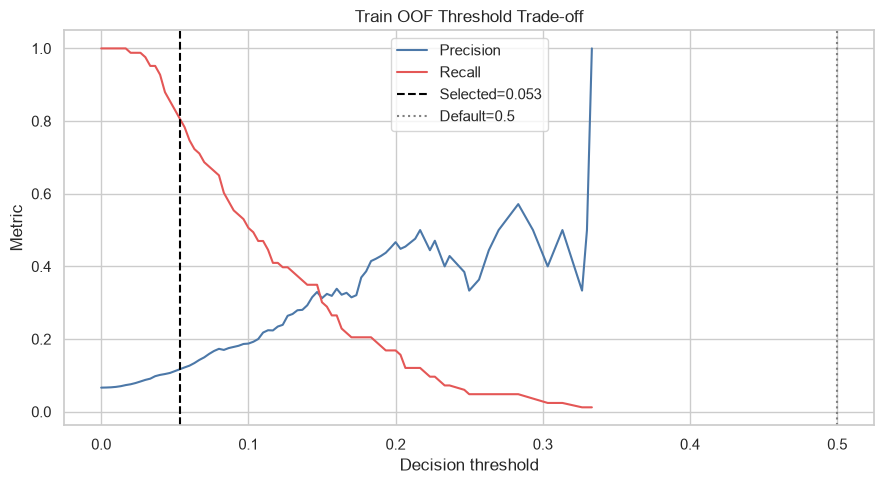

In [6]:
oof_probability = cross_val_predict(
    clone(selected_estimator), X_train[selected_features], y_train, cv=CV, method='predict_proba', n_jobs=1
)[:, 1]
oof_precision, oof_recall, oof_thresholds = precision_recall_curve(y_train, oof_probability)
threshold_table = pd.DataFrame({
    'threshold': oof_thresholds, 'precision': oof_precision[:-1], 'recall': oof_recall[:-1]
})
threshold_table['f1'] = 2 * threshold_table['precision'] * threshold_table['recall'] / (threshold_table['precision'] + threshold_table['recall']).replace(0, np.nan)
threshold_table['predicted_positive'] = [(oof_probability >= threshold).sum() for threshold in threshold_table['threshold']]
threshold_table['false_negative'] = [int(((oof_probability < threshold) & y_train.eq(1)).sum()) for threshold in threshold_table['threshold']]
recall_constrained = threshold_table[threshold_table['recall'] >= 0.80]
if recall_constrained.empty:
    raise RuntimeError('No threshold satisfies the declared recall constraint.')
selected_threshold_row = recall_constrained.sort_values(['precision', 'threshold'], ascending=[False, False]).iloc[0]
selected_threshold = float(selected_threshold_row['threshold'])
default_threshold_row = pd.Series({
    'threshold': 0.5,
    'precision': precision_score(y_train, oof_probability >= 0.5, zero_division=0),
    'recall': recall_score(y_train, oof_probability >= 0.5),
    'f1': f1_score(y_train, oof_probability >= 0.5),
    'predicted_positive': int((oof_probability >= 0.5).sum()),
    'false_negative': int(((oof_probability < 0.5) & y_train.eq(1)).sum()),
})
display(pd.DataFrame([default_threshold_row, selected_threshold_row]))
threshold_table.to_csv(REPORTS_DIR / 'model_threshold_tradeoff.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_table['threshold'], threshold_table['precision'], label='Precision', color='#4C78A8')
ax.plot(threshold_table['threshold'], threshold_table['recall'], label='Recall', color='#E45756')
ax.axvline(selected_threshold, color='black', linestyle='--', label=f'Selected={selected_threshold:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default=0.5')
ax.set(title='Train OOF Threshold Trade-off', xlabel='Decision threshold', ylabel='Metric')
ax.legend()
fig.tight_layout()
threshold_figure = FIGURES_DIR / 'modeling_threshold_precision_recall.png'
fig.savefig(threshold_figure, dpi=160, bbox_inches='tight')
plt.show()

## 5. Single final hold-out evaluation

모델·subset·threshold 확정 후 선정 estimator를 전체 outer train에 fit하고 test probability를 한 번 계산한다. 0.5와 선택 threshold를 함께 보고하되 test 결과로 기준을 다시 바꾸지 않는다.

In [7]:
final_estimator = clone(selected_estimator)
final_estimator.fit(X_train[selected_features], y_train)
test_probability = final_estimator.predict_proba(X_test[selected_features])[:, 1]
test_ap = average_precision_score(y_test, test_probability)
test_roc_auc = roc_auc_score(y_test, test_probability)

def evaluate_threshold(threshold):
    prediction = (test_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction, labels=[0, 1]).ravel()
    return {
        'threshold': float(threshold), 'pr_auc': float(test_ap), 'roc_auc': float(test_roc_auc),
        'precision_fail': float(precision_score(y_test, prediction, zero_division=0)),
        'recall_fail': float(recall_score(y_test, prediction)),
        'f1_fail': float(f1_score(y_test, prediction)),
        'balanced_accuracy': float(balanced_accuracy_score(y_test, prediction)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }
test_results = pd.DataFrame([
    {'threshold_label': 'default_0.5', **evaluate_threshold(0.5)},
    {'threshold_label': 'train_oof_recall_constraint', **evaluate_threshold(selected_threshold)},
])
test_results.to_csv(REPORTS_DIR / 'final_test_results.csv', index=False)
display(test_results)

,threshold_label,threshold,pr_auc,roc_auc,precision_fail,recall_fail,f1_fail,balanced_accuracy,tn,fp,fn,tp
0,default_0.5,0.500000,0.233475,0.798391,0.000000,0.000000,0.000000,0.500000,293,0,21,0
1,train_oof_recall_constraint,0.053333,0.233475,0.798391,0.133333,0.857143,0.230769,0.728913,176,117,3,18


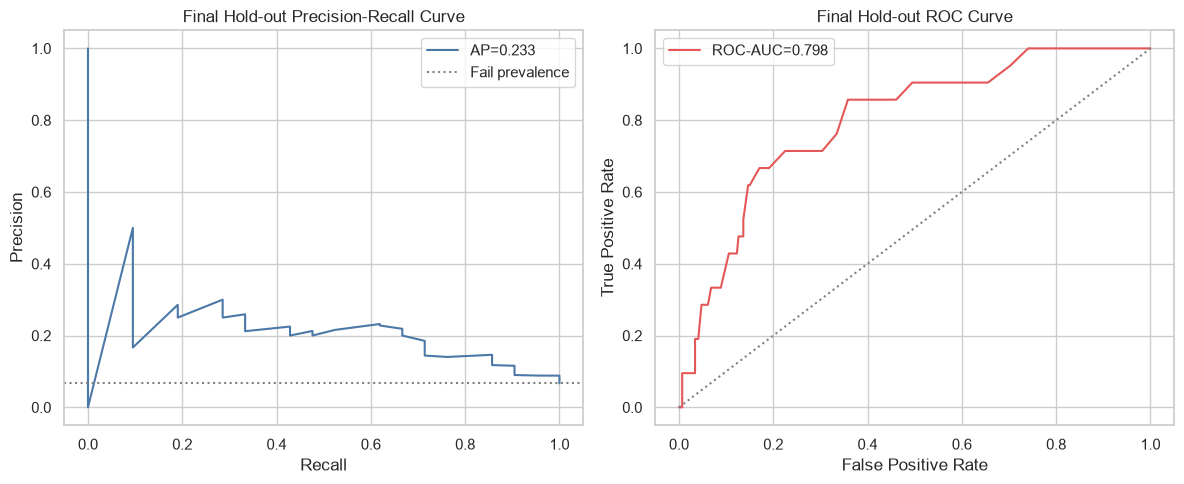

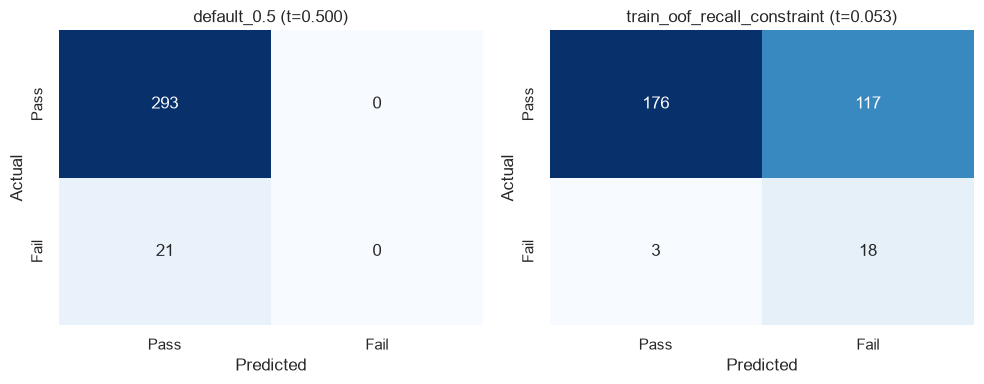

In [8]:
test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, test_probability)
test_fpr, test_tpr, _ = roc_curve(y_test, test_probability)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(test_recall_curve, test_precision_curve, color='#4C78A8', label=f'AP={test_ap:.3f}')
axes[0].axhline(y_test.mean(), color='gray', linestyle=':', label='Fail prevalence')
axes[0].set(title='Final Hold-out Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[0].legend()
axes[1].plot(test_fpr, test_tpr, color='#E45756', label=f'ROC-AUC={test_roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[1].set(title='Final Hold-out ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].legend()
fig.tight_layout()
curves_figure = FIGURES_DIR / 'modeling_final_pr_roc_curves.png'
fig.savefig(curves_figure, dpi=160, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, row in zip(axes, test_results.to_dict(orient='records')):
    matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]])
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, xticklabels=['Pass', 'Fail'], yticklabels=['Pass', 'Fail'])
    ax.set(title=f"{row['threshold_label']} (t={row['threshold']:.3f})", xlabel='Predicted', ylabel='Actual')
fig.tight_layout()
confusion_figure = FIGURES_DIR / 'modeling_confusion_matrices.png'
fig.savefig(confusion_figure, dpi=160, bbox_inches='tight')
plt.show()

## 6. Save summary and handoff candidates

In [9]:
selected_test_row = test_results[test_results['threshold_label'] == 'train_oof_recall_constraint'].iloc[0]
summary = {
    'scope': 'Modeling only; test evaluated once after CV model and OOF threshold selection',
    'split': {'train_samples': len(X_train), 'test_samples': len(X_test), 'train_fails': int(y_train.sum()), 'test_fails': int(y_test.sum())},
    'cv': {'type': 'StratifiedKFold', 'n_splits': 5, 'shuffle': True, 'random_state': RANDOM_STATE, 'primary_metric': 'average_precision'},
    'best_raw_cv_combination': cv_results.iloc[0].to_dict(),
    'selected_by_simplicity_rule': selected_row.to_dict(),
    'selected_model': selected_model_name, 'selected_subset': selected_subset_name,
    'selected_feature_count': len(selected_features),
    'threshold_rule': 'Maximize train OOF precision subject to recall >= 0.80; tie-break by higher threshold',
    'selected_threshold': selected_threshold,
    'oof_default_threshold': default_threshold_row.to_dict(),
    'oof_selected_threshold': selected_threshold_row.to_dict(),
    'final_test_results': test_results.to_dict(orient='records'),
    'explainability_candidates': explainability_candidates,
    'limitations': [
        'C/D subsets were preselected on the outer train rather than nested within every CV fold.',
        'No SMOTE, PCA, SHAP, exhaustive tuning, or external boosting library was used.',
        'The hold-out test was not used to revise the model or threshold.'
    ],
}
(REPORTS_DIR / 'modeling_summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "scope": "Modeling only; test evaluated once after CV model and OOF threshold selection",
  "split": {
    "train_samples": 1253,
    "test_samples": 314,
    "train_fails": 83,
    "test_fails": 21
  },
  "cv": {
    "type": "StratifiedKFold",
    "n_splits": 5,
    "shuffle": true,
    "random_state": 42,
    "primary_metric": "average_precision"
  },
  "best_raw_cv_combination": {
    "subset": "D_correlation_plus_model_based",
    "feature_count": 91,
    "model": "RandomForest_balanced",
    "cv_average_precision_mean": 0.274255355690491,
    "cv_average_precision_std": 0.03116257347805489,
    "cv_roc_auc_mean": 0.7839225113122172,
    "cv_roc_auc_std": 0.036624025373031915,
    "cv_recall_fail_mean": 0.0,
    "cv_recall_fail_std": 0.0,
    "cv_precision_fail_mean": 0.0,
    "cv_precision_fail_std": 0.0,
    "cv_f1_fail_mean": 0.0,
    "cv_f1_fail_std": 0.0,
    "cv_balanced_accuracy_mean": 0.5,
    "cv_balanced_accuracy_std": 0.0
  },
  "selected_by_simplicity_rule": {
    "

## Scope boundary

선정 후보는 다음 explainability 단계의 입력이다. Test 결과를 근거로 재선택하지 않았고 모델 파일도 저장하지 않았다.